# **Saúde Fetal**

**Autor**: Renan Santos Mendes

**Email**: renansantosmendes@gmail.com

**Descrição**: Este notebook apresenta um exemplo de modelo de aprendizado de máquina para um problema de classificação.


# **Saúde Fetal**

As Cardiotocografias (CTGs) são opções simples e de baixo custo para avaliar a saúde fetal, permitindo que os profissionais de saúde atuem na prevenção da mortalidade infantil e materna. O próprio equipamento funciona enviando pulsos de ultrassom e lendo sua resposta, lançando luz sobre a frequência cardíaca fetal (FCF), movimentos fetais, contrações uterinas e muito mais.

Este conjunto de dados contém 2126 registros de características extraídas de exames de Cardiotocografias, que foram então classificados por três obstetras especialistas em 3 classes:

- Normal
- Suspeito
- Patológico

In [1]:
 import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt

#from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 2 - Fazendo a leitura do dataset e atribuindo às respectivas variáveis

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/renansantosmendes/lectures-cdas-2023/master/fetal_health_reduced.csv')

In [ ]:
data

,severe_decelerations,accelerations,fetal_movement,uterine_contractions,fetal_health
0,0.0,0.0,0.0,0.0,2.0
1,0.0,6.0,0.0,6.0,1.0
2,0.0,3.0,0.0,8.0,1.0
3,0.0,3.0,0.0,8.0,1.0
4,0.0,7.0,0.0,8.0,1.0
...,...,...,...,...,...
2121,0.0,0.0,0.0,7.0,2.0
2122,0.0,1.0,0.0,7.0,2.0
2123,0.0,1.0,0.0,7.0,2.0
2124,0.0,1.0,0.0,6.0,2.0


# 3 - Preparando o dado antes de iniciar o treino do modelo

In [3]:
X = data.iloc[:,:-1]
y = data["fetal_health"]

In [4]:
scaler = StandardScaler()
X_df = scaler.fit_transform(X)
X_df = pd.DataFrame(X_df, columns=list(X.columns))

In [5]:
X_df.head()

,severe_decelerations,accelerations,fetal_movement,uterine_contractions
0,-0.057476,-0.822388,-0.20321,-1.482465
1,-0.057476,0.730133,-0.20321,0.554627
2,-0.057476,-0.046128,-0.20321,1.233657
3,-0.057476,-0.046128,-0.20321,1.233657
4,-0.057476,0.988886,-0.20321,1.233657


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_df,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=42)

In [29]:
data['fetal_health'].value_counts()

,count
fetal_health,
1.0,1655
2.0,295
3.0,176


In [7]:
from sklearn.metrics import accuracy_score

### **Distribuição das Classes**

Visualização da contagem de cada categoria de saúde fetal.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_df,
                                                    y,
                                                    test_size=0.3,
                                                    stratify=y,
                                                    random_state=42)

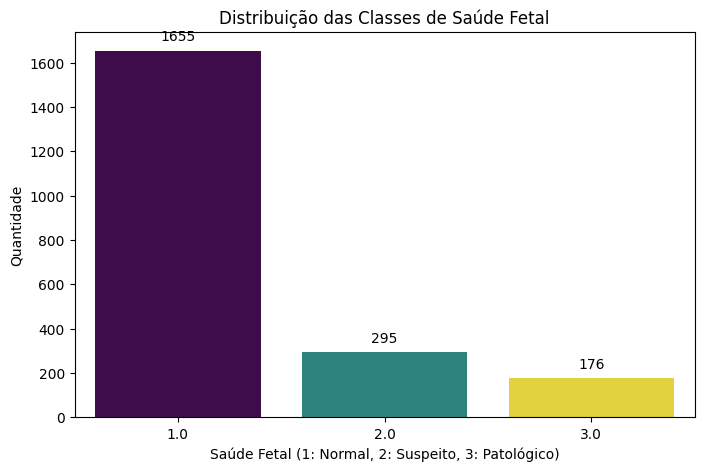

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_fetal_health_distribution(df):
    """Gera um gráfico de barras da distribuição das classes de saúde fetal."""
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(x='fetal_health', data=df, palette='viridis', hue='fetal_health', legend=False)

    plt.title('Distribuição das Classes de Saúde Fetal')
    plt.xlabel('Saúde Fetal (1: Normal, 2: Suspeito, 3: Patológico)')
    plt.ylabel('Quantidade')

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')

    plt.show()

# Chamando a função
plot_fetal_health_distribution(data)

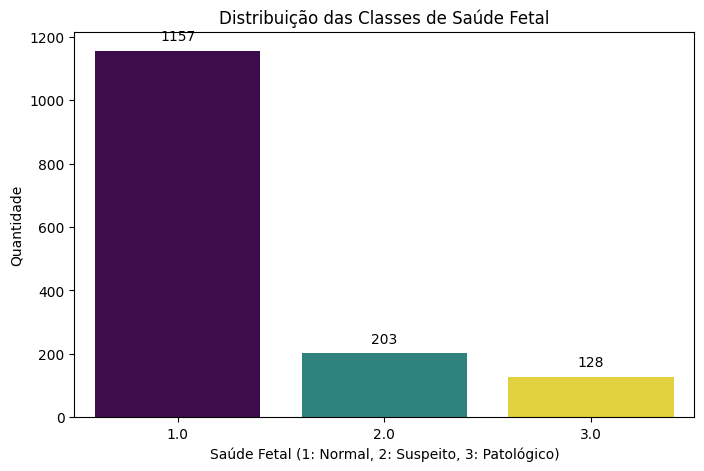

In [49]:
_, _, y_train_random, y_test_random = train_test_split(X_df,
                                                    y,
                                                    test_size=0.3,
                                                    # stratify=y,
                                                    )

plot_fetal_health_distribution(y_train_random.to_frame())

In [37]:
1655 + 295 + 176

2126

In [39]:
2126*0.7

1488.1999999999998

In [40]:
1488*0.77

1145.76

In [38]:
1655/2126

0.7784571966133584

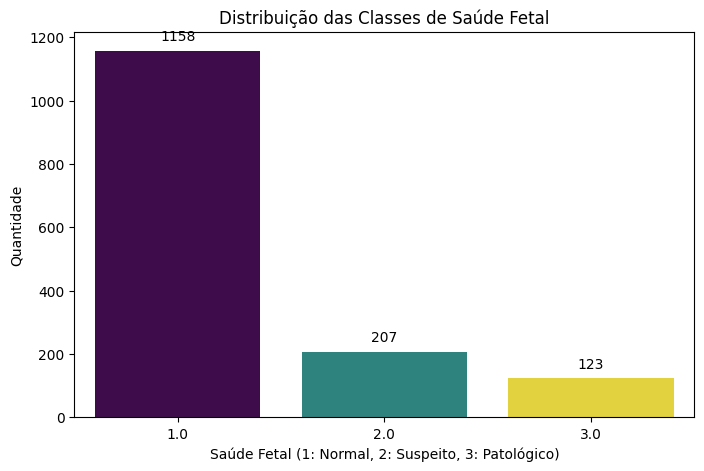

In [35]:
y_train_df = y_train.to_frame()
plot_fetal_health_distribution(y_train_df)

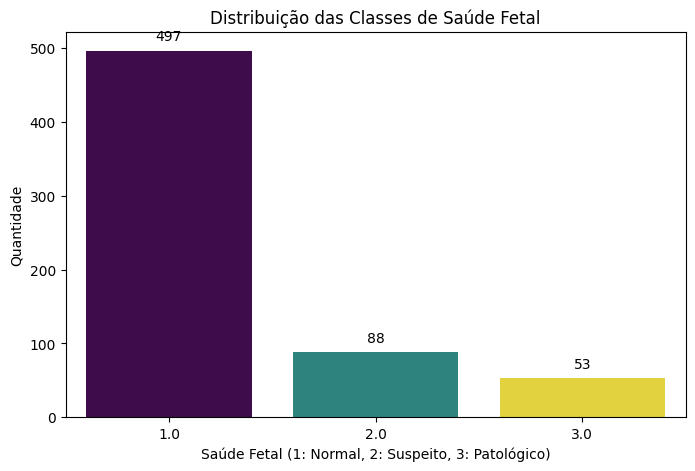

In [36]:
y_test_df = y_test.to_frame()
plot_fetal_health_distribution(y_test_df)

### **Cálculo de Pesos das Classes**

Para lidar com o desequilíbrio de classes, calculamos pesos inversamente proporcionais à frequéncia de cada classe.

In [50]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculando os pesos
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))

print("Pesos calculados para cada classe:")
for cls, weight in class_weights_dict.items():
    print(f"Classe {cls}: {weight:.4f}")

# Criando o sample_weight para modelos que não aceitam o dicionário diretamente no .fit()
sample_weights = np.array([class_weights_dict[cls] for cls in y_train])

Pesos calculados para cada classe:
Classe 1.0: 0.4283
Classe 2.0: 2.3961
Classe 3.0: 4.0325


# **Random Forest**

In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
%%time
tree_clf = DecisionTreeClassifier()

tree_clf.fit(X_train, y_train)

CPU times: user 6.23 ms, sys: 0 ns, total: 6.23 ms
Wall time: 11.7 ms


DecisionTreeClassifier()

In [10]:
y_pred = tree_clf.predict(X_test)
print(accuracy_score(y_true=y_test, y_pred=y_pred))

0.8040752351097179


# **Modelos Ensemble**

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

In [52]:
%%time
grd_clf = GradientBoostingClassifier(
    max_depth=7,
    n_estimators=200,
    learning_rate=0.001,
    random_state=42
    )

# Correção: Usando o array sample_weights em vez do dicionário
grd_clf.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = grd_clf.predict(X_test)
print(accuracy_score(y_true=y_test, y_pred=y_pred))

0.6379310344827587
CPU times: user 3.65 s, sys: 6.42 ms, total: 3.66 s
Wall time: 3.68 s


### **4 - Otimização com Grid Search**

Vamos utilizar o `GridSearchCV` para encontrar a melhor combinação de hiperparâmetros para o Gradient Boosting.

In [20]:
%%time
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01],
    'max_depth': [10, 15]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

print("Iniciando Grid Search...")
grid_search.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor acurácia no treino: {grid_search.best_score_:.4f}")

Iniciando Grid Search...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Melhores parâmetros: {'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 100}
Melhor acurácia no treino: 0.7930
CPU times: user 2.9 s, sys: 58.2 ms, total: 2.96 s
Wall time: 48.7 s


In [25]:
y_pred_best = grid_search.best_estimator_.predict(X_test)

In [27]:
best_model = grid_search.best_estimator_

### **6 - Métricas Detalhadas**

Vamos visualizar o `classification_report` e a `ConfusionMatrixDisplay` para entender o desempenho por classe.

In [53]:
best_model = grd_clf
y_pred_best = best_model.predict(X_test)

Relatório de Classificação:
              precision    recall  f1-score   support

         1.0       0.95      0.66      0.78       497
         2.0       0.29      0.65      0.40        88
         3.0       0.24      0.43      0.31        53

    accuracy                           0.64       638
   macro avg       0.49      0.58      0.50       638
weighted avg       0.80      0.64      0.69       638



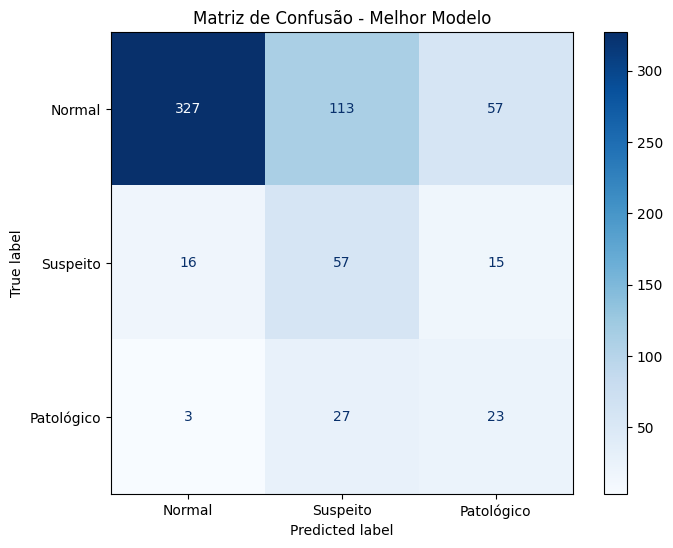

In [54]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Relatório de classificação
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_best))

# Plot da matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, display_labels=['Normal', 'Suspeito', 'Patológico'], ax=ax, cmap='Blues')
plt.title('Matriz de Confusão - Melhor Modelo')
plt.show()

### **5 - Avaliação do Melhor Modelo**

Agora, vamos testar o modelo otimizado nos dados de teste.

In [55]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Acurácia final (Melhor Modelo):", accuracy_score(y_test, y_pred_best))

Acurácia final (Melhor Modelo): 0.829153605015674


In [56]:
import pickle

In [57]:
pickle.dump(grd_clf, open("asd_o9.pkl", 'wb'))

In [58]:
model = pickle.load(open("asd_o9.pkl", 'rb'))

In [59]:
model

GradientBoostingClassifier(learning_rate=0.001, max_depth=7, n_estimators=200,
                           random_state=42)

In [60]:
model.predict(X_test)

array([3., 1., 2., 1., 2., 1., 1., 1., 2., 3., 2., 2., 2., 2., 2., 3., 1.,
       2., 1., 1., 2., 1., 1., 2., 1., 2., 2., 1., 3., 1., 2., 2., 1., 1.,
       1., 2., 1., 1., 2., 1., 1., 3., 1., 1., 1., 1., 2., 1., 2., 2., 3.,
       1., 1., 1., 1., 1., 1., 2., 1., 1., 2., 1., 1., 2., 1., 1., 2., 1.,
       1., 2., 1., 1., 3., 1., 1., 1., 1., 1., 3., 1., 1., 1., 1., 1., 1.,
       1., 1., 2., 1., 3., 1., 2., 1., 1., 2., 1., 1., 1., 1., 1., 3., 1.,
       2., 1., 1., 1., 1., 3., 1., 1., 1., 2., 1., 3., 3., 2., 3., 2., 1.,
       2., 3., 1., 1., 1., 1., 3., 2., 2., 1., 2., 1., 2., 2., 1., 2., 1.,
       1., 1., 1., 2., 1., 1., 2., 2., 1., 2., 1., 2., 2., 3., 2., 1., 2.,
       1., 3., 2., 1., 3., 1., 2., 1., 2., 3., 1., 2., 3., 2., 3., 1., 1.,
       2., 1., 3., 3., 2., 1., 2., 1., 3., 1., 1., 1., 1., 1., 2., 2., 3.,
       1., 1., 1., 3., 2., 3., 2., 1., 1., 2., 1., 2., 1., 1., 1., 1., 1.,
       1., 2., 1., 1., 1., 2., 2., 1., 1., 3., 2., 1., 1., 1., 2., 2., 1.,
       1., 2., 2., 1., 1.

In [65]:
%%capture
!uv pip install mlflow dagshub

In [62]:
import os
import mlflow

os.environ['MLFLOW_TRACKING_USERNAME'] = 'renansantosmendes'
os.environ['MLFLOW_TRACKING_PASSWORD'] = 'cc41cc48f8e489dd5b87404dd6f9720944e32e9b '
mlflow.set_tracking_uri = "https://dagshub.com/renansantosmendes/asia_asd_o9.mlflow"

In [67]:
# import mlflow
# import dagshub
# #
# dagshub.init(repo_owner='renansantosmendes', repo_name='asia_asd_o9', mlflow=True)

Initialized MLflow to track repo "renansantosmendes/asia_asd_o9"

Repository renansantosmendes/asia_asd_o9 initialized!

In [68]:
mlflow.sklearn.autolog(log_input_examples=True)

In [70]:
%%time
grd_clf = GradientBoostingClassifier(
    max_depth=7,
    n_estimators=250,
    learning_rate=0.001,
    random_state=42
    )

grd_clf.fit(X_train, y_train, sample_weight=sample_weights)

2026/03/06 00:50:58 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'bcbeb344c90c4ccd97b9d1668919f832', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/03/06 00:51:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/06 00:51:14 WARNING mlflow.sklearn.utils: roc_auc_score failed. The metric training_roc_auc will not be recorded. Metric error: sample_weight is not supported for multiclass one-vs-one ROC AUC, 'sample_weight' must be None in this case.


🏃 View run luminous-yak-811 at: https://dagshub.com/renansantosmendes/asia_asd_o9.mlflow/#/experiments/0/runs/bcbeb344c90c4ccd97b9d1668919f832
🧪 View experiment at: https://dagshub.com/renansantosmendes/asia_asd_o9.mlflow/#/experiments/0
CPU times: user 6.22 s, sys: 57.9 ms, total: 6.28 s
Wall time: 19.5 s


GradientBoostingClassifier(learning_rate=0.001, max_depth=7, n_estimators=250,
                           random_state=42)

In [71]:
from mlflow.tracking import MlflowClient

In [72]:
client = MlflowClient()

In [73]:
logged_models = client.search_logged_models(['0'])

In [76]:
logged_models[0].model_uri

'models:/m-91ddf0b1127f42778768d22ee0798ea6'

In [77]:
loaded_model = mlflow.pyfunc.load_model(logged_models[0].model_uri)

In [78]:
loaded_model

mlflow.pyfunc.loaded_model:
  artifact_path: mlflow-artifacts:/5d2f764186854daa8dfc88b03d97be0b/models/m-91ddf0b1127f42778768d22ee0798ea6/artifacts
  flavor: mlflow.sklearn
  run_id: bcbeb344c90c4ccd97b9d1668919f832

In [79]:
loaded_model.predict(X_test)

array([3., 1., 2., 1., 2., 1., 1., 1., 2., 3., 2., 2., 2., 2., 2., 3., 1.,
       2., 1., 1., 1., 1., 1., 2., 1., 2., 2., 1., 3., 1., 2., 2., 1., 1.,
       1., 2., 1., 1., 2., 1., 1., 3., 1., 1., 1., 1., 2., 1., 2., 2., 3.,
       1., 1., 1., 1., 1., 1., 2., 1., 1., 2., 1., 1., 2., 1., 1., 2., 1.,
       1., 2., 1., 1., 3., 1., 1., 1., 1., 1., 3., 1., 1., 1., 1., 1., 1.,
       1., 1., 2., 1., 3., 1., 2., 1., 1., 2., 1., 1., 1., 1., 1., 3., 1.,
       2., 1., 1., 1., 1., 3., 1., 1., 1., 2., 1., 3., 3., 2., 3., 2., 1.,
       2., 3., 1., 1., 1., 1., 3., 2., 2., 1., 2., 1., 2., 2., 1., 2., 1.,
       1., 1., 1., 2., 1., 1., 2., 2., 1., 2., 1., 2., 2., 3., 2., 1., 2.,
       1., 3., 1., 1., 3., 1., 2., 1., 2., 3., 1., 2., 3., 2., 3., 1., 1.,
       2., 1., 3., 3., 2., 1., 2., 1., 3., 1., 1., 1., 1., 1., 2., 2., 3.,
       1., 1., 1., 3., 2., 3., 2., 1., 1., 2., 1., 2., 1., 1., 1., 1., 1.,
       1., 2., 1., 2., 1., 2., 2., 1., 1., 3., 2., 1., 1., 1., 2., 2., 1.,
       1., 2., 2., 1., 1.